In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

FEATURE_COLS = [
    "acousticness",
    "danceability",
    "duration_ms",
    "energy",
    "instrumentalness",
    "key",
    "liveness",
    "loudness",
    "mode",
    "speechiness",
    "tempo",
    "time_signature",
    "valence",
    "popularity"
]

ID_COL = "id"
NAME_COL = "name"
LABEL_COL = "category_name"

LABEL_TO_IDX = {"active": 0, "relax": 1}
IDX_TO_LABEL = {0: "active", 1: "relax"}

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


Final dataset size: 15858
Train / Val / Test: 11099 2378 2381

Class counts:
category_name
active    8124
relax     7734
Name: count, dtype: int64


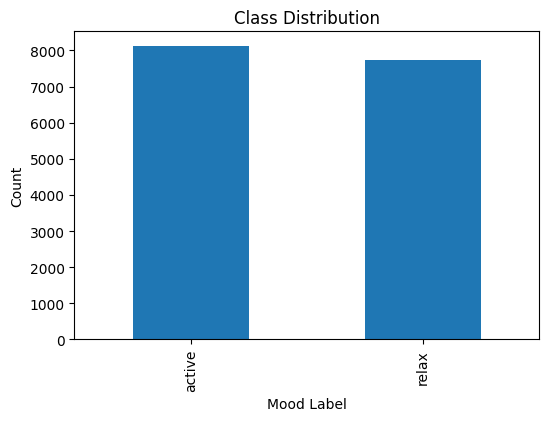

,id,name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,...,popularity,category_name,label,energy_valence,dance_energy,acoustic_instr,loudness_energy,speech_energy,log_duration_ms,log_tempo
0,087fGGq27BXXpxKAlbBwNM,Rhythm Is A Dancer - 7' Edit,0.2730,0.794,225882,0.745,0.000414,9.0,0.143,-11.367,...,32,relax,1,0.525970,0.591530,0.000113,-8.468415,0.027565,12.327772,4.830304
1,0CsM8VGDi38kusMv3pxyj1,True - Single Edit,0.4590,0.742,329146,0.533,0.148000,0.0,0.064,-9.098,...,73,relax,1,0.208403,0.395486,0.067932,-4.849234,0.015350,12.704260,4.588990
2,0DiWol3AO6WpXZgp0goxAV,One More Time,0.0194,0.613,320357,0.697,0.000000,2.0,0.332,-8.618,...,80,relax,1,0.331772,0.427261,0.000000,-6.006746,0.092701,12.677194,4.818231
3,0LzeivEHO16a8eBQGlpVkE,Love Shack - Edit; 2019 Remaster,0.1100,0.704,262586,0.828,0.000000,5.0,0.747,-7.304,...,61,relax,1,0.717048,0.582912,0.000000,-6.047712,0.042559,12.478338,4.901534
4,0MHXrqn909p0LRTPsNsGEi,Move on Up - Single Edit,0.4170,0.538,165789,0.969,0.001540,11.0,0.119,-5.626,...,73,relax,1,0.899232,0.521322,0.000642,-5.451594,0.087791,12.018477,4.939154



All features used:
['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'popularity', 'energy_valence', 'dance_energy', 'acoustic_instr', 'loudness_energy', 'speech_energy', 'log_duration_ms', 'log_tempo']


In [2]:
clear_df = pd.read_csv("spotify_clear_data.csv")
replaced_df = pd.read_csv("spotify_replaced.csv")

clear_df = clear_df[[ID_COL, NAME_COL] + FEATURE_COLS + [LABEL_COL]].copy()
replaced_df = replaced_df[[ID_COL, NAME_COL] + FEATURE_COLS + [LABEL_COL]].copy()

clear_df = clear_df[clear_df[LABEL_COL].isin(["active", "relax"])].copy()
replaced_df = replaced_df[replaced_df[LABEL_COL].isin(["active", "relax"])].copy()

replaced_df = replaced_df.dropna(subset=FEATURE_COLS + [LABEL_COL]).copy()
replaced_df = replaced_df.drop_duplicates(subset=[ID_COL]).copy()

new_rows_from_replaced = replaced_df[~replaced_df[ID_COL].isin(clear_df[ID_COL])].copy()
combined_df = pd.concat([clear_df, new_rows_from_replaced], axis=0).reset_index(drop=True)

combined_df["label"] = combined_df[LABEL_COL].map(LABEL_TO_IDX)

def add_engineered_features(df):
    df = df.copy()

    df["energy_valence"] = df["energy"] * df["valence"]
    df["dance_energy"] = df["danceability"] * df["energy"]
    df["acoustic_instr"] = df["acousticness"] * df["instrumentalness"]
    df["loudness_energy"] = df["loudness"] * df["energy"]
    df["speech_energy"] = df["speechiness"] * df["energy"]

    df["log_duration_ms"] = np.log1p(df["duration_ms"].clip(lower=0))
    df["log_tempo"] = np.log1p(df["tempo"].clip(lower=0))

    return df

combined_df = add_engineered_features(combined_df)

EXTRA_FEATURE_COLS = [
    "energy_valence",
    "dance_energy",
    "acoustic_instr",
    "loudness_energy",
    "speech_energy",
    "log_duration_ms",
    "log_tempo"
]

ALL_FEATURE_COLS = FEATURE_COLS + EXTRA_FEATURE_COLS

def stratified_split(df, label_col="label", train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42):
    train_parts, val_parts, test_parts = [], [], []

    for label_value in sorted(df[label_col].unique()):
        group = df[df[label_col] == label_value].sample(frac=1.0, random_state=seed).reset_index(drop=True)

        n = len(group)
        n_train = int(n * train_frac)
        n_val = int(n * val_frac)

        train_parts.append(group.iloc[:n_train])
        val_parts.append(group.iloc[n_train:n_train + n_val])
        test_parts.append(group.iloc[n_train + n_val:])

    train_df = pd.concat(train_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_df = pd.concat(val_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    test_df = pd.concat(test_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return train_df, val_df, test_df

train_df, val_df, test_df = stratified_split(combined_df)

train_means = train_df[ALL_FEATURE_COLS].mean()
train_stds = train_df[ALL_FEATURE_COLS].std().replace(0, 1)

def standardize(df, feature_cols, means, stds):
    df = df.copy()
    df[feature_cols] = (df[feature_cols] - means) / stds
    return df

train_df = standardize(train_df, ALL_FEATURE_COLS, train_means, train_stds)
val_df = standardize(val_df, ALL_FEATURE_COLS, train_means, train_stds)
test_df = standardize(test_df, ALL_FEATURE_COLS, train_means, train_stds)

print("Final dataset size:", len(combined_df))
print("Train / Val / Test:", len(train_df), len(val_df), len(test_df))
print("\nClass counts:")
print(combined_df[LABEL_COL].value_counts())

plt.figure(figsize=(6, 4))
combined_df[LABEL_COL].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Mood Label")
plt.ylabel("Count")
plt.show()

display(combined_df.head())
print("\nAll features used:")
print(ALL_FEATURE_COLS)

In [3]:
class SpotifyMoodDataset(Dataset):
    def __init__(self, df, feature_cols, label_col="label"):
        self.X = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[label_col].values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SpotifyMoodDataset(train_df, ALL_FEATURE_COLS)
val_dataset = SpotifyMoodDataset(val_df, ALL_FEATURE_COLS)
test_dataset = SpotifyMoodDataset(test_df, ALL_FEATURE_COLS)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_accuracy(model, data_loader, device="cpu"):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)
            outputs = model(features)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

def get_predictions(model, data_loader, device="cpu"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            outputs = model(features)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

def confusion_matrix_numpy(y_true, y_pred, num_classes=2):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label, pred_label] += 1
    return cm

def plot_curves(history, title_prefix="Model"):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"])
    plt.title(f"{title_prefix} Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def train_model_basic(model, train_loader, val_loader, num_epochs=20, learning_rate=1e-3, device="cpu"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_acc = get_accuracy(model, train_loader, device=device)
        val_acc = get_accuracy(model, val_loader, device=device)

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1:02d} | Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc

def train_model_advanced(model, train_loader, val_loader, num_epochs=60, learning_rate=3e-4, weight_decay=1e-4, patience=10, device="cpu"):
    class_counts = train_df["label"].value_counts().sort_index().values
    class_weights = len(train_df) / (len(class_counts) * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None
    epochs_without_improvement = 0

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_acc = get_accuracy(model, train_loader, device=device)
        val_acc = get_accuracy(model, val_loader, device=device)

        scheduler.step(val_acc)

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d} | Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc

In [4]:
class BaselineANN(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_classes=2):
        super(BaselineANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),

            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return x + self.block(x)

class BetterTabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_blocks=3, num_classes=2, dropout=0.2):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.Sequential(*[
            ResidualBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)
        ])

        self.head = nn.Sequential(
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),

            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.blocks(x)
        x = self.head(x)
        return x

BaselineANN(
  (net): Sequential(
    (0): Linear(in_features=21, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)
Baseline parameters: 834
Epoch 01 | Loss: 0.6215 | Train Acc: 0.6820 | Val Acc: 0.6695
Epoch 02 | Loss: 0.5837 | Train Acc: 0.6882 | Val Acc: 0.6682
Epoch 03 | Loss: 0.5752 | Train Acc: 0.6903 | Val Acc: 0.6758
Epoch 04 | Loss: 0.5700 | Train Acc: 0.6987 | Val Acc: 0.6846
Epoch 05 | Loss: 0.5661 | Train Acc: 0.6964 | Val Acc: 0.6804
Epoch 06 | Loss: 0.5642 | Train Acc: 0.6999 | Val Acc: 0.6943
Epoch 07 | Loss: 0.5614 | Train Acc: 0.7066 | Val Acc: 0.6976
Epoch 08 | Loss: 0.5573 | Train Acc: 0.7065 | Val Acc: 0.6934
Epoch 09 | Loss: 0.5572 | Train Acc: 0.7047 | Val Acc: 0.6871
Epoch 10 | Loss: 0.5545 | Train Acc: 0.7067 | Val Acc: 0.6930
Epoch 11 | Loss: 0.5531 | Train Acc: 0.7124 | Val Acc: 0.6934
Epoch 12 | Loss: 0.5512 | Tra

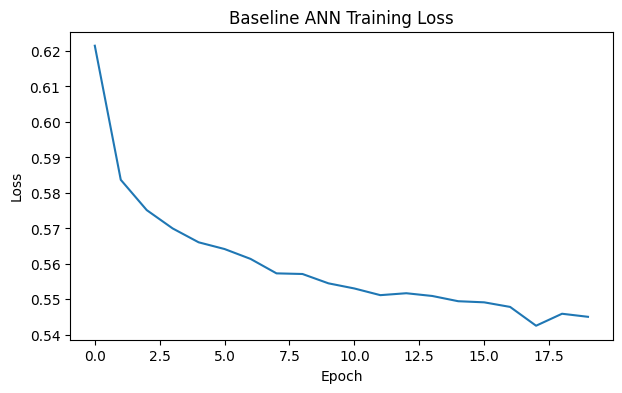

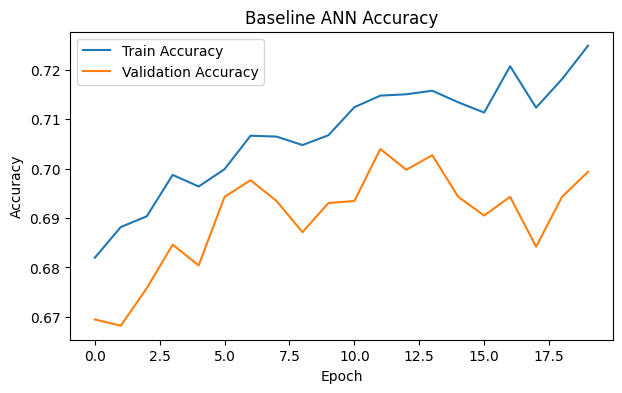

Baseline best validation accuracy: 0.704
Baseline test accuracy: 0.6909


In [5]:
baseline_model = BaselineANN(input_dim=len(ALL_FEATURE_COLS), hidden_dim=32, num_classes=2)
print(baseline_model)
print("Baseline parameters:", count_parameters(baseline_model))

baseline_history, baseline_best_val_acc = train_model_basic(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=20,
    learning_rate=1e-3,
    device=device
)

plot_curves(baseline_history, title_prefix="Baseline ANN")

baseline_test_acc = get_accuracy(baseline_model, test_loader, device=device)
print("Baseline best validation accuracy:", round(baseline_best_val_acc, 4))
print("Baseline test accuracy:", round(baseline_test_acc, 4))

BetterTabularMLP(
  (input_proj): Linear(in_features=21, out_features=128, bias=True)
  (blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.15, inplace=False)
        (3): Linear(in_features=128, out_features=128, bias=True)
        (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): GELU(approximate='none')
        (6): Dropout(p=0.15, inplace=False)
        (7): Linear(in_features=128, out_features=128, bias=True)
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.15, inplace=False)
        (3): Linear(in_features=128, out_features=128, bias=True)
        (4): BatchNorm1d(128, eps=1e-05, momentu

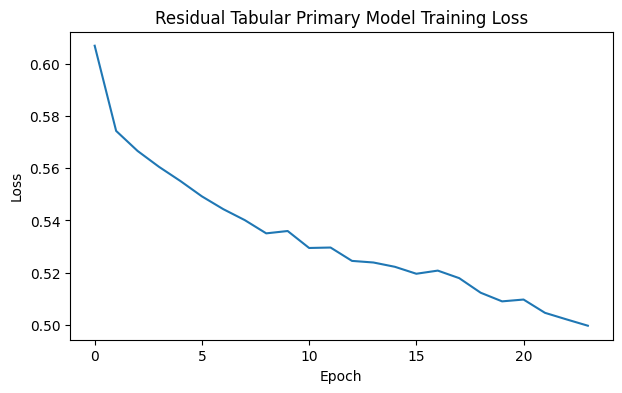

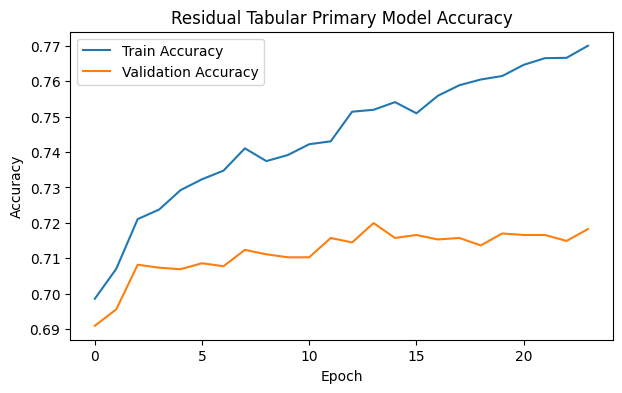

Primary best validation accuracy: 0.7199
Primary test accuracy: 0.7026
Confusion Matrix:
[[899 321]
 [387 774]]


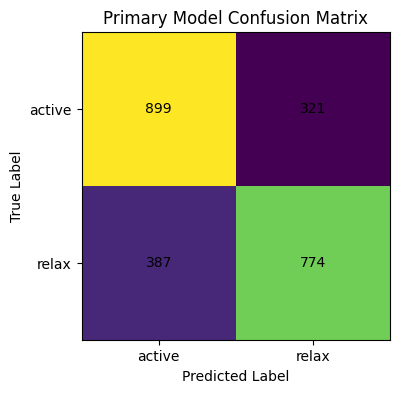

Correct predictions:


,name,true_label_name,pred_label_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,...,time_signature,valence,popularity,energy_valence,dance_energy,acoustic_instr,loudness_energy,speech_energy,log_duration_ms,log_tempo
1,Muy Tarde,active,active,0.848270,0.933209,-0.894817,-0.817436,1.377429,0.783327,-0.510321,...,0.255272,-1.146708,-0.567543,-0.971972,-0.509442,1.275937,-0.332695,-0.604955,-1.085170,-0.070149
4,Sauce - Manoo Buzzin Vocal,active,active,-1.073839,0.809033,-0.012894,0.819228,-0.754508,1.629884,0.013499,...,0.255272,0.029848,-2.116954,0.319029,1.125407,-0.582683,-0.567435,-0.306750,0.155225,0.369965
8,AEIOU,active,active,-0.950033,0.651425,-0.611179,1.100840,-0.767742,-0.063231,0.338101,...,0.255272,1.179664,0.752326,1.640317,1.280357,-0.582718,0.428198,0.402406,-0.629570,0.400629
11,Índigo,relax,relax,-1.056453,0.933209,0.066681,0.845732,-0.767643,-1.474159,-0.419305,...,0.255272,2.027701,0.924482,2.176719,1.247179,-0.582717,-0.228027,-0.322963,0.246053,0.476722
13,Trankobuskas - Remix,active,active,-0.256436,0.837689,-1.115617,0.756279,-0.767652,-0.345416,1.490122,...,0.255272,-0.581350,0.694940,-0.260072,1.082341,-0.582685,-0.086804,0.207542,-1.493115,-0.400234
15,Çok Geç Kaldın,active,active,-0.814049,-1.110924,1.117031,0.418345,-0.767742,1.065512,-0.132891,...,-1.694669,-0.611910,-0.338001,-0.396643,-0.505680,-0.582718,0.297106,-0.171337,1.246480,0.815624
16,PERO TÚ,active,active,-0.043385,1.472899,-0.335195,0.882176,-0.767742,0.218955,-0.432034,...,0.255272,1.084164,1.498338,1.340187,1.703288,-0.582718,0.227507,3.109552,-0.242680,0.758755
17,WHERE DOES YOUR SPIRIT GO?,active,active,0.385346,-0.905555,-0.109003,-0.499380,-0.767742,-0.909788,-0.247456,...,2.205213,-0.214631,0.867097,-0.518136,-0.845318,-0.582718,0.520322,-0.482498,0.041839,-1.126432
18,Reach - Will Clarke Remix,active,active,-1.054691,0.197704,0.200099,1.296312,-0.767322,0.783327,-0.787188,...,0.255272,1.806142,-1.256170,2.507574,1.063881,-0.582713,-0.515806,0.197537,0.392591,0.505507
19,Without A Word,relax,relax,1.290152,0.126063,0.368564,-1.168623,-0.766977,1.629884,-0.432034,...,0.255272,-0.031272,-0.682314,-0.792607,-1.015555,-0.581903,0.550874,-0.685394,0.568213,0.670076


Incorrect predictions:


,name,true_label_name,pred_label_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,...,time_signature,valence,popularity,energy_valence,dance_energy,acoustic_instr,loudness_energy,speech_energy,log_duration_ms,log_tempo
0,Seninle Hayaller,relax,active,-1.058189,-0.318106,-0.330378,0.252690,-0.767742,1.065512,4.080578,...,0.255272,-0.627190,-1.084013,-0.461106,-0.114588,-0.582718,-0.332995,-0.461815,-0.236340,0.759870
2,Drive By,relax,active,-1.076890,1.014402,-0.175572,1.037891,-0.767715,-1.191973,-0.628705,...,0.255272,1.236964,1.440953,1.636431,1.516701,-0.582718,0.514373,-0.320562,-0.039208,0.286776
3,Sunshine,relax,active,-1.060056,0.689633,0.042865,0.812602,-0.767742,-1.474159,-0.671985,...,0.255272,1.622782,0.121084,1.765994,1.028715,-0.582718,0.442787,0.040095,0.219148,-0.400717
5,Some Place Else,active,relax,-0.551024,0.465160,0.066068,-0.141567,1.466812,-1.474159,-0.432034,...,0.255272,-0.883129,-0.567543,-0.732320,-0.016114,-0.051809,-0.061701,-0.543009,0.245364,-1.004577
6,For Once In My Life - Remastered/1994,active,relax,1.142858,-1.024956,-0.274376,-1.234885,-0.767595,0.501141,-0.381116,...,0.255272,-0.990089,-0.223229,-0.999254,-1.239970,-0.582571,0.603754,-0.693079,-0.163566,-0.304308
7,Impersonator,active,relax,-1.065659,0.818585,-0.137240,0.706583,0.704581,1.629884,-0.050149,...,0.255272,1.569303,-1.485712,1.600327,1.017464,-0.573424,-0.675939,0.224081,0.007720,0.513703
9,Night Light,active,relax,1.521614,-2.278181,-0.760428,-1.583421,1.526400,-0.063231,-0.470223,...,-1.694669,-1.341146,-0.682314,-1.083968,-1.462534,2.099223,0.946326,-0.742422,-0.860914,-2.076631
10,Kusur,active,relax,-0.918207,0.584561,-0.062980,-0.383422,-0.767739,-1.474159,-0.581606,...,0.255272,-1.221198,-1.084013,-0.950480,-0.190374,-0.582718,-0.024225,-0.337423,0.096655,0.762000
12,The touch of your lips,active,relax,1.505833,-0.356314,3.703028,-1.709451,1.168871,1.347698,-0.470223,...,0.255272,-0.695950,-0.452772,-1.085972,-1.461380,1.667523,1.207862,-0.764851,2.851105,0.059473
14,WITHOUT YOU (with Miley Cyrus),relax,active,-0.624671,0.489040,-0.617517,-0.181324,-0.767742,-1.474159,-0.530051,...,0.255272,0.266687,1.039254,-0.102724,-0.041633,-0.582718,0.419781,-0.541616,-0.639049,-0.668745


Saved model to spotify_residual_primary_model.pt

Summary
Baseline parameters: 834
Primary parameters: 112194
Baseline best val acc: 0.704
Baseline test acc: 0.6909
Primary best val acc: 0.7199
Primary test acc: 0.7026


In [7]:
primary_model = BetterTabularMLP(
    input_dim=len(ALL_FEATURE_COLS),
    hidden_dim=128,
    num_blocks=3,
    num_classes=2,
    dropout=0.15
)

print(primary_model)
print("Primary model parameters:", count_parameters(primary_model))

primary_history, primary_best_val_acc = train_model_advanced(
    model=primary_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=60,
    learning_rate=3e-4,
    weight_decay=1e-4,
    patience=10,
    device=device
)

plot_curves(primary_history, title_prefix="Residual Tabular Primary Model")

primary_test_acc = get_accuracy(primary_model, test_loader, device=device)
print("Primary best validation accuracy:", round(primary_best_val_acc, 4))
print("Primary test accuracy:", round(primary_test_acc, 4))

primary_preds, primary_true = get_predictions(primary_model, test_loader, device=device)
cm = confusion_matrix_numpy(primary_true, primary_preds, num_classes=2)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Primary Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["active", "relax"])
plt.yticks([0, 1], ["active", "relax"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.show()

test_results_df = test_df.copy().reset_index(drop=True)
test_results_df["true_label_name"] = test_results_df["label"].map(IDX_TO_LABEL)
test_results_df["pred_label"] = primary_preds
test_results_df["pred_label_name"] = test_results_df["pred_label"].map(IDX_TO_LABEL)
test_results_df["correct"] = test_results_df["label"] == test_results_df["pred_label"]

print("Correct predictions:")
display(test_results_df[test_results_df["correct"]].head(10)[[NAME_COL, "true_label_name", "pred_label_name"] + ALL_FEATURE_COLS])

print("Incorrect predictions:")
display(test_results_df[~test_results_df["correct"]].head(10)[[NAME_COL, "true_label_name", "pred_label_name"] + ALL_FEATURE_COLS])

torch.save(primary_model.state_dict(), "spotify_residual_primary_model.pt")
print("Saved model to spotify_residual_primary_model.pt")

print("\nSummary")
print("Baseline parameters:", count_parameters(baseline_model))
print("Primary parameters:", count_parameters(primary_model))
print("Baseline best val acc:", round(baseline_best_val_acc, 4))
print("Baseline test acc:", round(baseline_test_acc, 4))
print("Primary best val acc:", round(primary_best_val_acc, 4))
print("Primary test acc:", round(primary_test_acc, 4))